In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

VARIANT = 1
np.random.seed(VARIANT)

july_mean_temp = 21.0

In [3]:
daily_temps = np.random.normal(loc=july_mean_temp, scale=2.5, size=30)

print(f"Згенерована вибірка денних температур (перші 10 значень):\n{daily_temps[:10].round(2)}")
print(f"\nСереднє вибірки (.mean()): {daily_temps.mean():.2f} °C")
print(f"Стандартне відхилення вибірки (.std()): {daily_temps.std():.2f} °C")

Згенерована вибірка денних температур (перші 10 значень):
[25.06 19.47 19.68 18.32 23.16 15.25 25.36 19.1  21.8  20.38]

Середнє вибірки (.mean()): 20.85 °C
Стандартне відхилення вибірки (.std()): 2.52 °C


In [4]:
mean = daily_temps.mean()
std = daily_temps.std()

dist = stats.norm(loc=mean, scale=std)

print(f"Підібрані параметри розподілу: μ = {mean:.2f}, σ = {std:.2f}")

Підібрані параметри розподілу: μ = 20.85, σ = 2.52


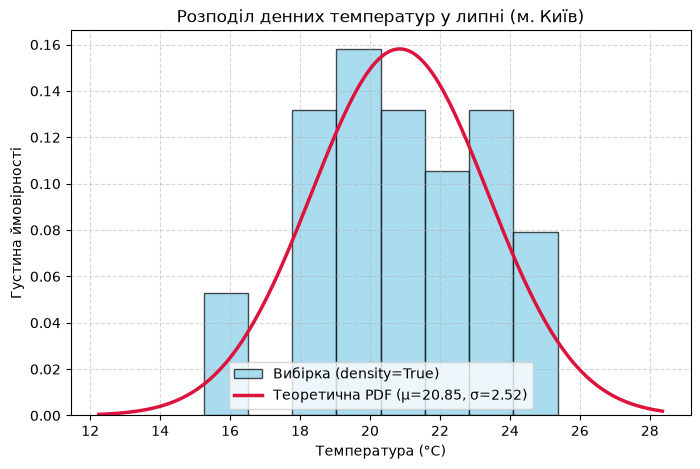

In [5]:
x = np.linspace(daily_temps.min() - 3, daily_temps.max() + 3, 200)

plt.figure(figsize=(8, 5))
plt.hist(daily_temps, bins=8, density=True, color="skyblue", edgecolor="black", alpha=0.7, label="Вибірка (density=True)")
plt.plot(x, dist.pdf(x), color="crimson", linewidth=2.5, label=f"Теоретична PDF (μ={mean:.2f}, σ={std:.2f})")

plt.title("Розподіл денних температур у липні (м. Київ)")
plt.xlabel("Температура (°C)")
plt.ylabel("Густина ймовірності")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [6]:
p_1std = dist.cdf(mean + std) - dist.cdf(mean - std)

print(f"Ймовірність потрапляння в інтервал [mean - std, mean + std]: {p_1std:.4f} ({p_1std * 100:.2f}%)")

Ймовірність потрапляння в інтервал [mean - std, mean + std]: 0.6827 (68.27%)


In [7]:
p95_temp = dist.ppf(0.95)

print(f"95-й процентиль (температура): {p95_temp:.2f} °C")

95-й процентиль (температура): 25.00 °C
